In [1]:
import os
import numpy as np

import jax
import jax.numpy as jnp
from jax import jacfwd, vmap
from functools import partial
from typing import NamedTuple, Sequence, Callable

import flax.linen as nn
import optax
from soap_jax import soap

import time
import scipy.io
import matplotlib.pyplot as plt

from flax import serialization

from Utilities_pinn_adsamp_burgers1d import *

interface x = 0.5 index = 256


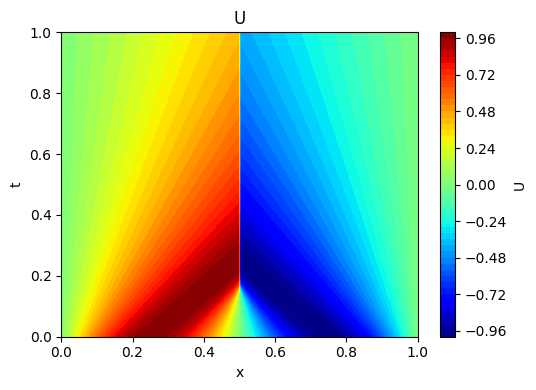

In [ ]:
# 1. Data
data = scipy.io.loadmat("burgers_godunov.mat")

U0 = jnp.asarray(data["U"][::2,::2])
X0 = jnp.asarray(data["X"][::2,::2])
T0 = jnp.asarray(data["T"][::2,::2])

Nt_test, Nx_test = U0.shape

T_grid = T0
X_grid = X0

t_test = T0.reshape(-1)
x_test = X0.reshape(-1)
test_labels = U0.reshape(-1, 1)

x_unique = np.unique(np.asarray(X0))
interface_idx = int(np.argmin(np.abs(x_unique - 0.5)))

print("interface x =", x_unique[interface_idx], "index =", interface_idx)

plt.figure(figsize=(5.5, 4))
plt.contourf(X0, T0, U0, levels=50, cmap='jet')
plt.colorbar(label='U')
plt.xlabel('x')
plt.ylabel('t')
plt.title('U')
plt.tight_layout()
plt.show()

In [3]:
# 2. Random keys
seed = 49
save_path = "pinn_adsamp_burgers_statistic10.msgpack"
key = jax.random.PRNGKey(seed)
# Keep the same initial PDE and Stage-1 training keys as the lifted run;
# the middle key would belong to coor_net in that implementation.
(key_pde_init, _, key_train) = jax.random.split(key, 3)

# 3. Vanilla PINN: physical coordinates [t, x] only
layer_sizes = [40, 40, 1]

pde_net = FNN_fourier(layer_sizes, fourier_dim=20)
pde_params = pde_net.init(key_pde_init, jnp.ones((2,)))

# 4. Optimizer
pde_optimizer = soap(learning_rate=3e-3, b1=0.95, b2=0.95, weight_decay=0.01, precondition_frequency=10, precondition_1d=False)

# 5. Common functions
pde_loss_grad_fn = create_pde_loss_grad_fn(pde_net)
eval_fn = create_eval_fn(pde_net, nx_test=Nx_test, interface_idx=interface_idx)
test_inputs = create_test_inputs(t_test, x_test)

[Stage 1] JIT warm-up finished.
[Stage 1] iter = 00000, time = 0.00s | mse = 1.44e+00, rl2 = 2.43e+00
[Stage 1] iter = 00100, time = 0.60s, loss = 4.32e-01 | mse = 7.74e-02, rl2 = 5.62e-01
[Stage 1] iter = 00200, time = 0.92s, loss = 1.97e-01 | mse = 3.20e-02, rl2 = 3.62e-01
[Stage 1] iter = 00300, time = 1.23s, loss = 3.23e-02 | mse = 1.29e-02, rl2 = 2.30e-01
[Stage 1] iter = 00400, time = 1.54s, loss = 4.11e-03 | mse = 1.01e-02, rl2 = 2.03e-01
[Stage 1] iter = 00500, time = 1.85s, loss = 1.10e-03 | mse = 9.77e-03, rl2 = 2.00e-01
[Stage 1] iter = 00600, time = 2.15s, loss = 7.85e-04 | mse = 9.70e-03, rl2 = 1.99e-01
[Stage 1] iter = 00700, time = 2.46s, loss = 4.10e-04 | mse = 9.68e-03, rl2 = 1.99e-01
[Stage 1] iter = 00800, time = 2.77s, loss = 2.57e-04 | mse = 9.64e-03, rl2 = 1.98e-01
[Stage 1] iter = 00900, time = 3.08s, loss = 2.68e-04 | mse = 9.65e-03, rl2 = 1.99e-01
[Stage 1] iter = 01000, time = 3.39s, loss = 2.06e-04 | mse = 9.61e-03, rl2 = 1.98e-01
[Stage 1] iter = 01100, time

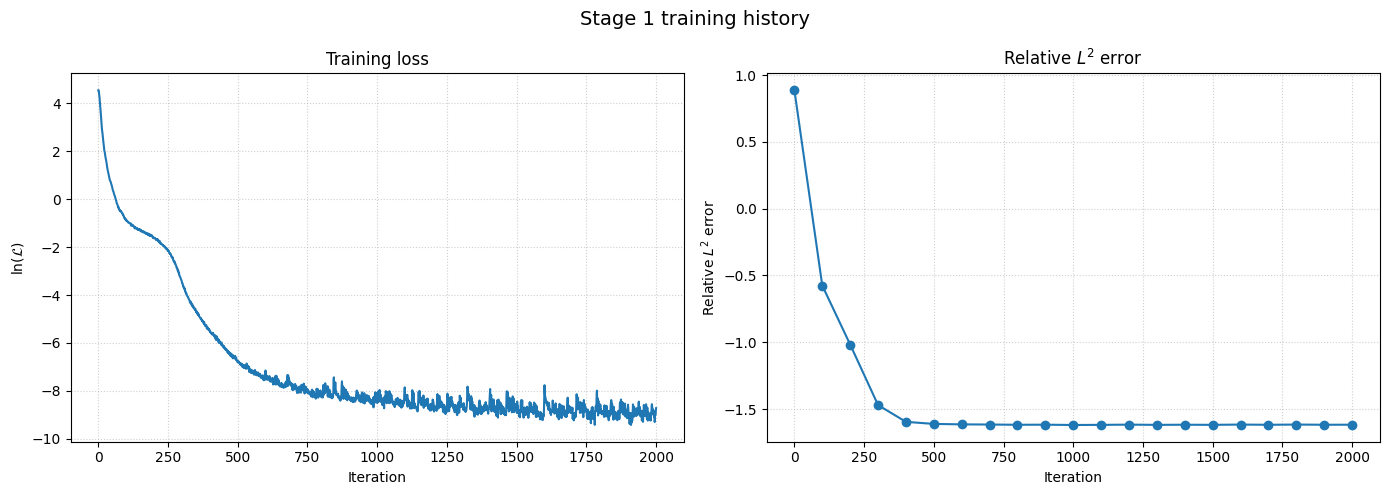

Plotting... Test grid shape: nt=513, nx=513
Interface detected at x = 0.50000000, index = 256
MSE = 9.652885e-03
 RL2 = 1.985213e-01


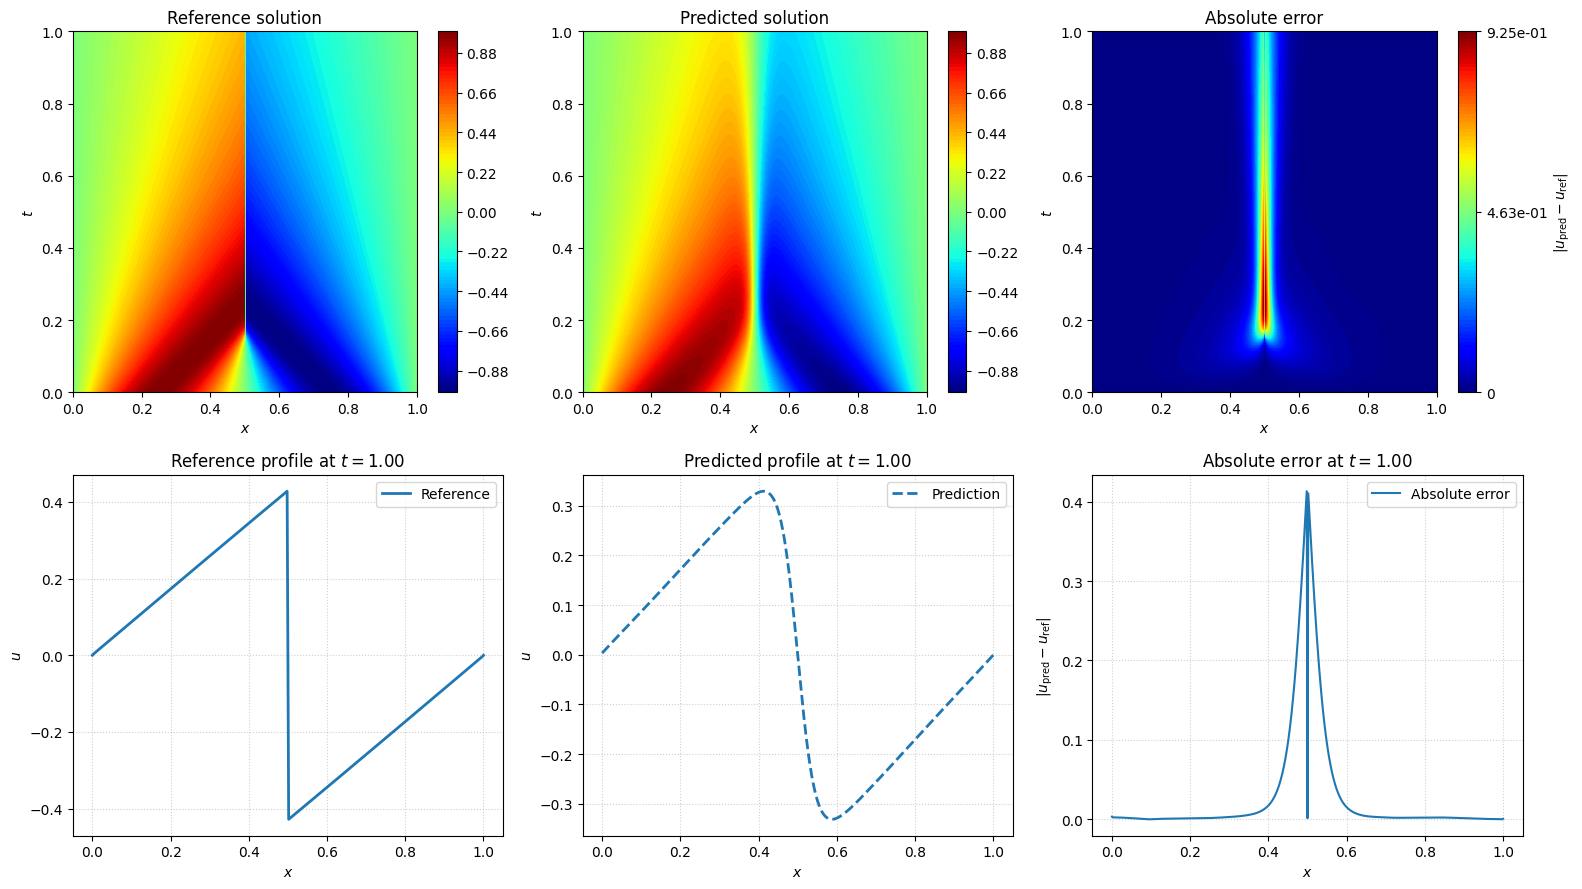

(np.float32(0.009652885), np.float32(0.19852129))

In [4]:
# Stage 1: uniform physical sampling because x = xi
minibatch_stage1 = create_pde_minibatch_fn(IC_Burgers, BC_Burgers, identity_map_xi_to_x)

pde_params, key_train, history_stage1 = train_pde_stage(stage_name="Stage 1",
    pde_params=pde_params, pde_optimizer=pde_optimizer, pde_loss_grad_fn=pde_loss_grad_fn, pde_minibatch_fn=minibatch_stage1,
    eval_fn=eval_fn, test_inputs=test_inputs, test_labels=test_labels,
    key=key_train, nu=1e-2, max_iters=2000, pts_pde=10000, pts_ics=1000, pts_bcs=1000, max_runtime=10000.0, eval_every=100)

pde_params_stage1 = pde_params

plot_training_history(history_stage1, metric="rl2", title="Stage 1 training history")
plot_evaluation(params=pde_params, model=pde_net, t_test=t_test, x_test=x_test, labels_test=test_labels, interface_x=0.5)

[Adaptive Mesh] time = 1.05 s
adaptive dx min = 1.817942e-04
adaptive dx max = 8.047879e-03
non-positive adaptive cells = 0


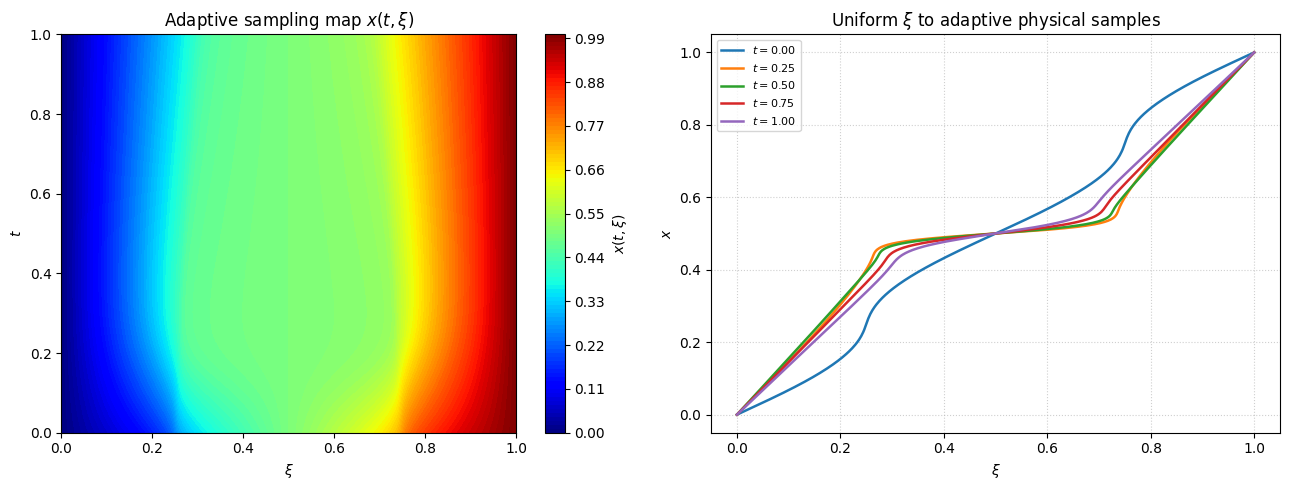

In [5]:
# Build the Stage-2 sampler from the Stage-1 vanilla-PINN solution.
(xi_grid, Xi_of_x, X_adapt, map_xi_to_x, U_stage1) = generate_adaptive_mesh(
    pde_net, pde_params, T_grid, X_grid
)
plot_adaptive_mesh(T_grid=T_grid, xi_grid=xi_grid, X_adapt=X_adapt)

[Stage 2] JIT warm-up finished.
[Stage 2] iter = 00000, time = 0.00s | mse = 9.65e-03, rl2 = 1.99e-01
[Stage 2] iter = 00100, time = 0.37s, loss = 4.27e-01 | mse = 3.63e-02, rl2 = 3.85e-01
[Stage 2] iter = 00200, time = 0.71s, loss = 3.91e-01 | mse = 3.13e-02, rl2 = 3.58e-01
[Stage 2] iter = 00300, time = 1.06s, loss = 3.23e-01 | mse = 2.45e-02, rl2 = 3.16e-01
[Stage 2] iter = 00400, time = 1.40s, loss = 2.27e-01 | mse = 1.51e-02, rl2 = 2.49e-01
[Stage 2] iter = 00500, time = 1.74s, loss = 1.28e-01 | mse = 1.61e-02, rl2 = 2.56e-01
[Stage 2] iter = 00600, time = 2.09s, loss = 5.65e-02 | mse = 1.20e-02, rl2 = 2.21e-01
[Stage 2] iter = 00700, time = 2.43s, loss = 3.23e-02 | mse = 4.47e-03, rl2 = 1.35e-01
[Stage 2] iter = 00800, time = 2.77s, loss = 2.13e-02 | mse = 1.28e-03, rl2 = 7.24e-02
[Stage 2] iter = 00900, time = 3.11s, loss = 1.41e-02 | mse = 7.19e-04, rl2 = 5.42e-02
[Stage 2] iter = 01000, time = 3.46s, loss = 1.02e-02 | mse = 9.97e-04, rl2 = 6.38e-02
[Stage 2] iter = 01100, time

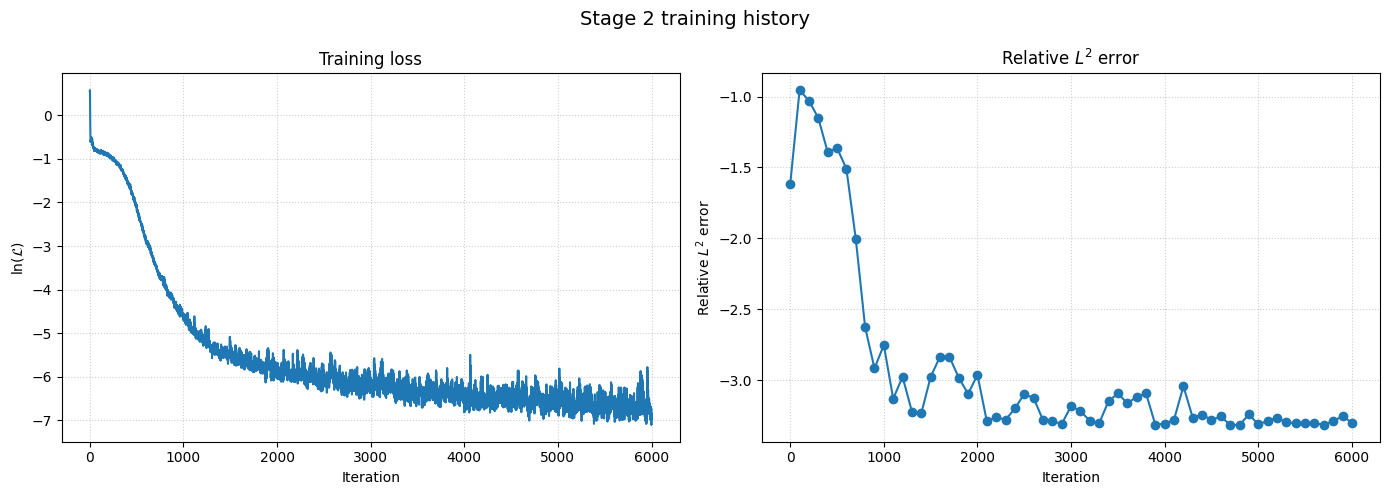

Plotting... Test grid shape: nt=513, nx=513
Interface detected at x = 0.50000000, index = 256
MSE = 3.334641e-04
 RL2 = 3.689802e-02


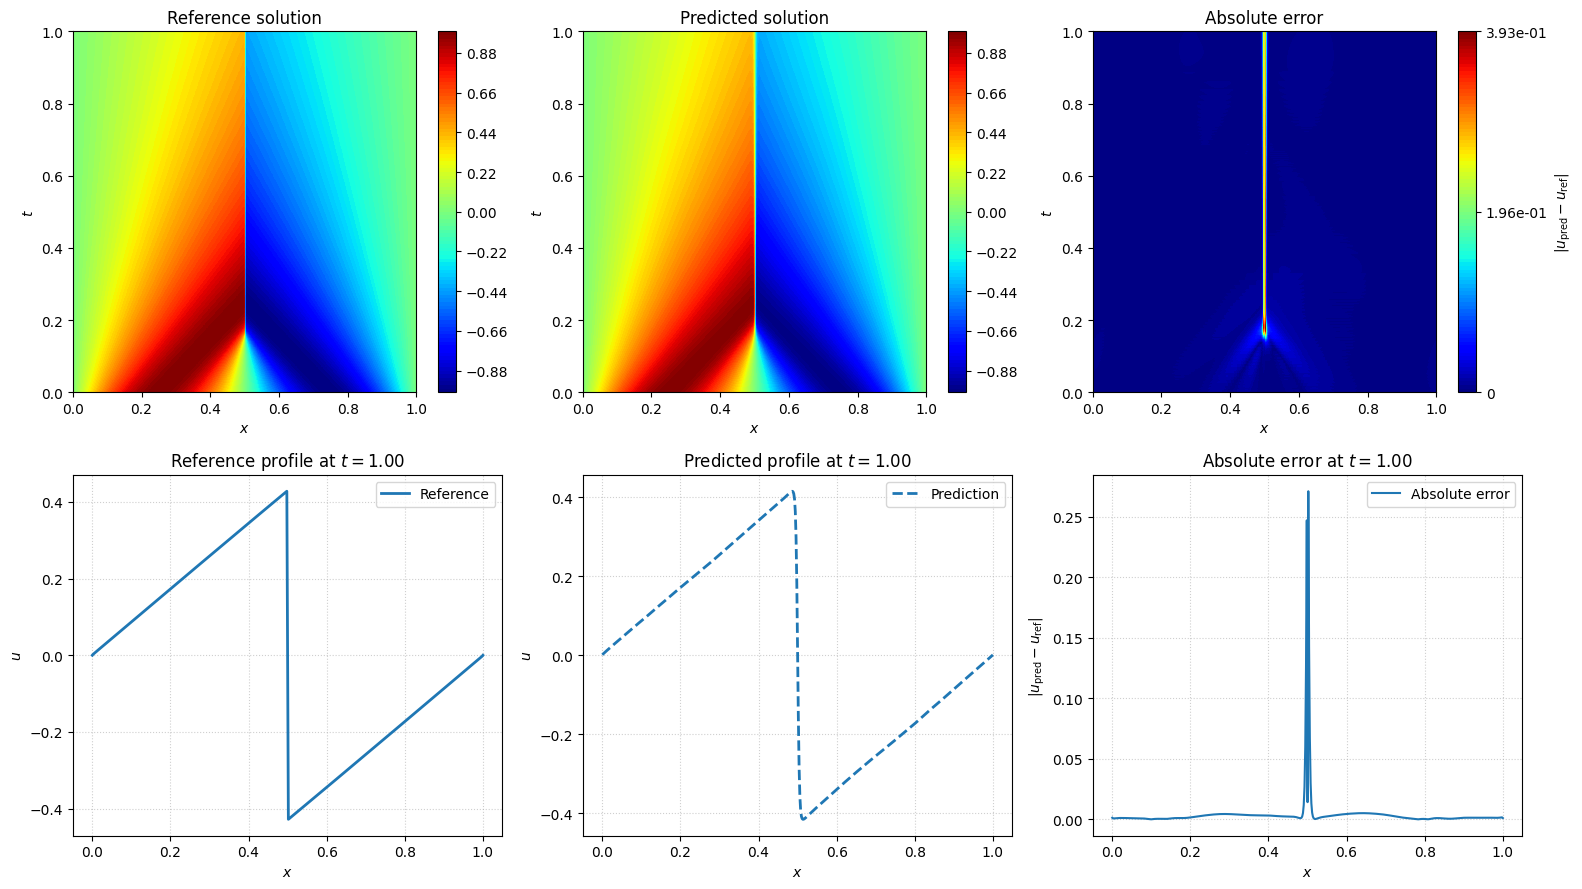

(np.float32(0.0003334641), np.float32(0.03689802))

In [6]:
# Stage 2: uniform in (t, xi), adaptive in physical (t, x)
minibatch_stage2 = create_pde_minibatch_fn(IC_Burgers, BC_Burgers, map_xi_to_x)

pde_params, key_train, history_stage2 = train_pde_stage(stage_name="Stage 2",
    pde_params=pde_params, pde_optimizer=pde_optimizer, pde_loss_grad_fn=pde_loss_grad_fn, pde_minibatch_fn=minibatch_stage2,
    eval_fn=eval_fn, test_inputs=test_inputs, test_labels=test_labels,
    key=key_train, nu=1e-3, max_iters=6000, pts_pde=10000, pts_ics=1000, pts_bcs=1000, max_runtime=10000.0, eval_every=100)

pde_params_stage2 = pde_params

plot_training_history(history_stage2, metric="rl2", title="Stage 2 training history")
plot_evaluation(params=pde_params, model=pde_net, t_test=t_test, x_test=x_test, labels_test=test_labels, interface_x=0.5)

[Adaptive Mesh] time = 0.02 s
adaptive dx min = 3.594160e-05
adaptive dx max = 8.175075e-03
non-positive adaptive cells = 0


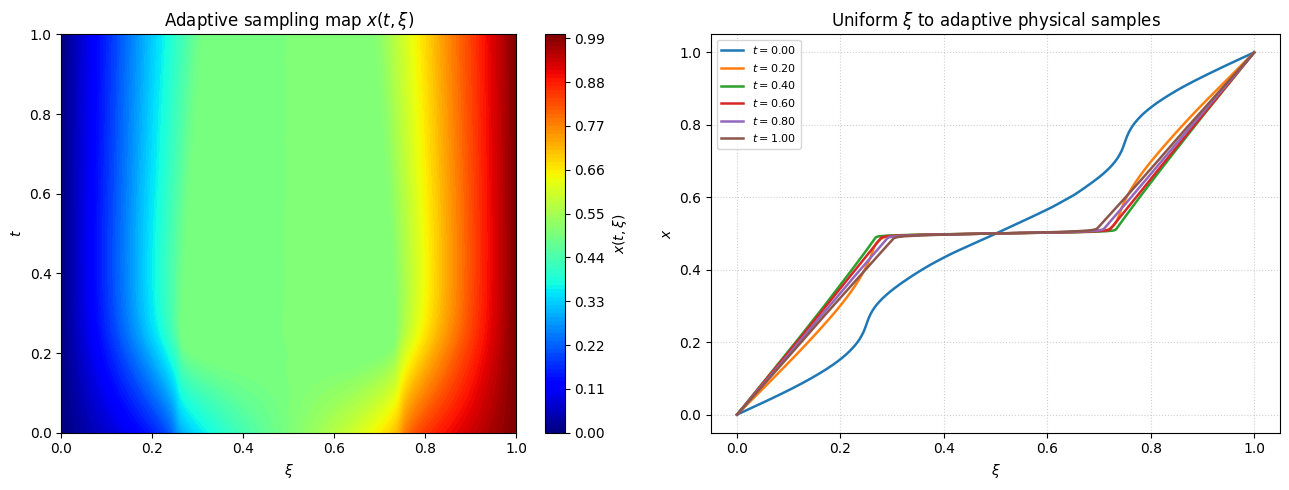

In [7]:
# Rebuild the sampler for Stage 3 from the Stage-2 solution.
(xi_grid, Xi_of_x, X_adapt, map_xi_to_x, U_stage2) = generate_adaptive_mesh(
    pde_net, pde_params, T_grid, X_grid
)
plot_adaptive_mesh(T_grid=T_grid, xi_grid=xi_grid, X_adapt=X_adapt, n_times=6)

[Stage 3] JIT warm-up finished.
[Stage 3] iter = 00000, time = 0.00s | mse = 3.33e-04, rl2 = 3.69e-02
[Stage 3] iter = 00100, time = 0.40s, loss = 5.13e-01 | mse = 4.52e-02, rl2 = 4.29e-01
[Stage 3] iter = 00200, time = 0.79s, loss = 4.65e-01 | mse = 4.34e-02, rl2 = 4.21e-01
[Stage 3] iter = 00300, time = 1.18s, loss = 4.63e-01 | mse = 3.84e-02, rl2 = 3.96e-01
[Stage 3] iter = 00400, time = 1.54s, loss = 4.51e-01 | mse = 3.77e-02, rl2 = 3.92e-01
[Stage 3] iter = 00500, time = 1.89s, loss = 4.46e-01 | mse = 3.70e-02, rl2 = 3.89e-01
[Stage 3] iter = 00600, time = 2.24s, loss = 4.51e-01 | mse = 3.44e-02, rl2 = 3.75e-01
[Stage 3] iter = 00700, time = 2.58s, loss = 4.29e-01 | mse = 3.58e-02, rl2 = 3.82e-01
[Stage 3] iter = 00800, time = 2.93s, loss = 4.59e-01 | mse = 4.29e-02, rl2 = 4.19e-01
[Stage 3] iter = 00900, time = 3.28s, loss = 4.21e-01 | mse = 3.60e-02, rl2 = 3.83e-01
[Stage 3] iter = 01000, time = 3.62s, loss = 4.26e-01 | mse = 4.00e-02, rl2 = 4.04e-01
[Stage 3] iter = 01100, time

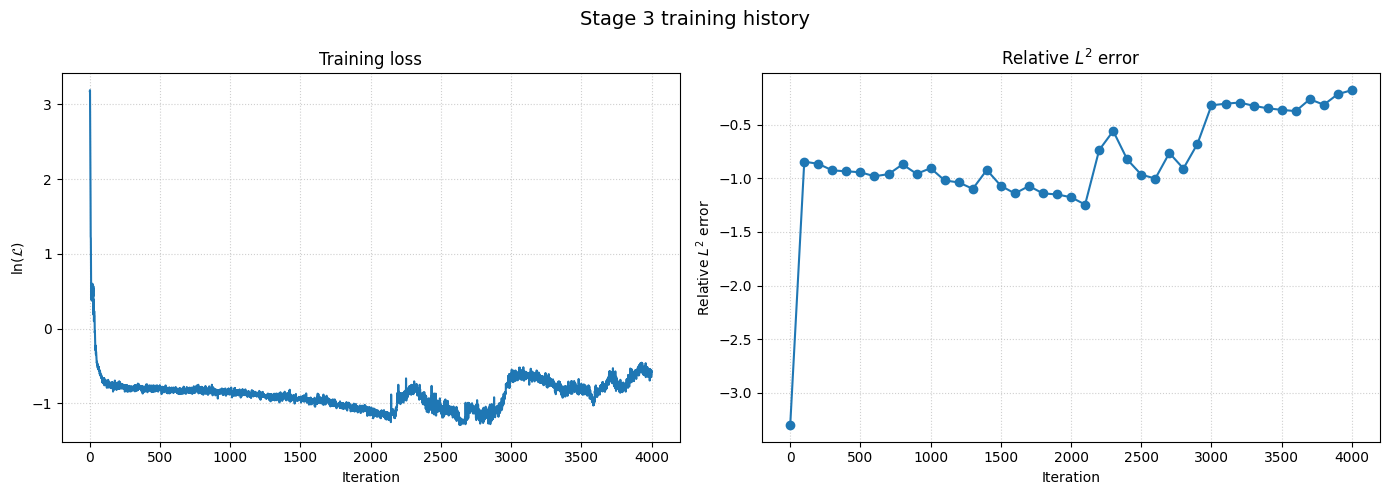

Plotting... Test grid shape: nt=513, nx=513
Interface detected at x = 0.50000000, index = 256
MSE = 1.711204e-01
 RL2 = 8.358521e-01


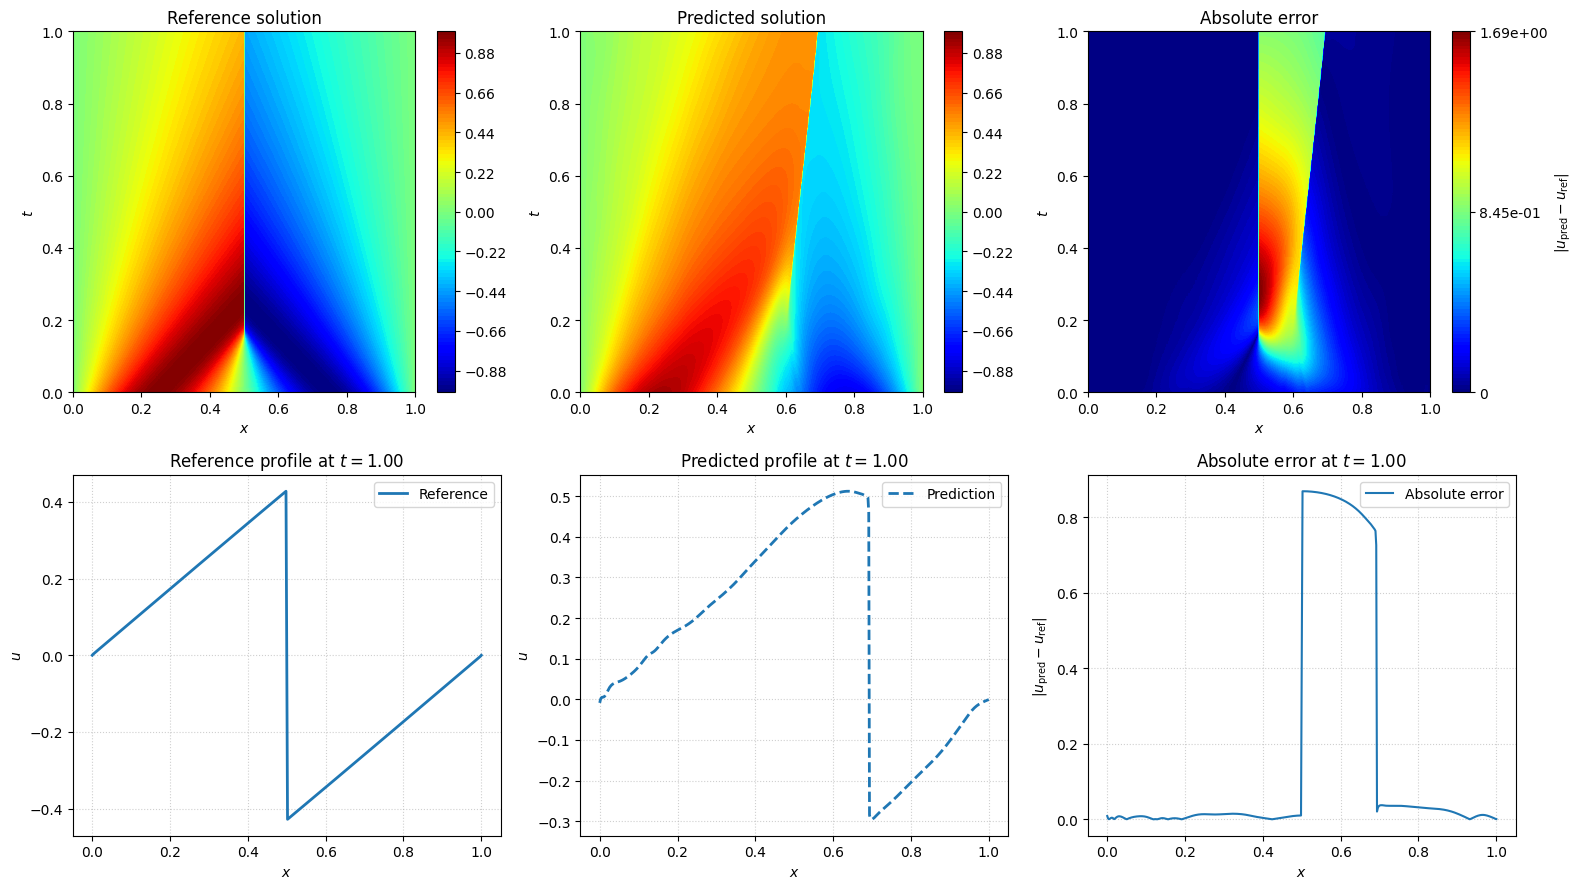

(np.float32(0.17112045), np.float32(0.83585215))

In [8]:
# Stage 3: uniform in (t, xi), adaptive in physical (t, x)
minibatch_stage3 = create_pde_minibatch_fn(IC_Burgers, BC_Burgers, map_xi_to_x)

pde_params, key_train, history_stage3 = train_pde_stage(stage_name="Stage 3",
    pde_params=pde_params, pde_optimizer=pde_optimizer, pde_loss_grad_fn=pde_loss_grad_fn, pde_minibatch_fn=minibatch_stage3,
    eval_fn=eval_fn, test_inputs=test_inputs, test_labels=test_labels,
    key=key_train, nu=1e-4, max_iters=4000, pts_pde=10000, pts_ics=1000, pts_bcs=1000, max_runtime=10000.0, eval_every=100)

pde_params_stage3 = pde_params

plot_training_history(history_stage3, metric="rl2", title="Stage 3 training history")
plot_evaluation(params=pde_params, model=pde_net, t_test=t_test, x_test=x_test, labels_test=test_labels, interface_x=0.5)

In [9]:
save_training_results(
    pde_params_by_stage={
        "stage1": pde_params_stage1,
        "stage2": pde_params_stage2,
        "stage3": pde_params_stage3,
    },
    pde_histories_by_stage={
        "stage1": history_stage1,
        "stage2": history_stage2,
        "stage3": history_stage3,
    },
    checkpoint_path=save_path,
)

Training checkpoint saved to: /home/DG21210022/Amon/tal/burgers/pinn_adsamp_burgers_statistic10.msgpack
Training histories saved to: /home/DG21210022/Amon/tal/burgers/pinn_adsamp_burgers_statistic10_history.npz
